In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("player_stats.csv")
df



,player,player_name,team,player_id,agents,agents_count,rounds,rating,acs,kd_ratio,...,fdpr,hs_percent,cl_percent,clutches,k_max,kills,deaths,assists,first_kills,first_deaths
0,t3xture,t3xture,GEN,9196,"['Neon', 'Jett', 'Raze']",3,255,1.23,258.2,1.44,...,0.17,28%,37%,7/19,27,239,166,48,54,43
1,Spring,Spring,WOL,14125,"['Viper', 'Astra', 'Omen']",3,349,1.21,244.1,1.23,...,0.09,29%,7%,2/29,26,295,240,111,47,31
2,Verno,Verno,MIBR,21668,['Sova'],1,71,1.18,230.5,1.02,...,0.04,28%,14%,3/22,19,56,55,21,3,3
3,Alfajer,Alfajer,FNC,9810,"['Iso', 'Raze', 'Cypher', 'Killjoy', 'Chamber'...",6,419,1.17,257.9,1.30,...,0.11,32%,12%,4/33,29,392,301,60,73,45
4,zekken,zekken,SEN,4004,"['Yoru', 'Raze', 'Omen', 'Neon', 'Waylay']",5,249,1.17,237.5,1.21,...,0.21,24%,17%,3/18,27,202,167,65,47,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Disguised Toast,Disguised Toast,Team,55812,['Cypher'],1,20,NaN,NaN,1.00,...,NaN,NaN,0%,NaN,12,12,12,5,0,0
67,Jacob,Jacob,Team,55811,['Gekko'],1,20,NaN,NaN,0.46,...,NaN,NaN,0%,NaN,6,6,13,5,0,0
68,meL,meL,Team,3063,['Omen'],1,20,NaN,NaN,2.56,...,NaN,NaN,0%,NaN,23,23,9,11,0,0
69,Sidsity,Sidsity,Team,48629,['Fade'],1,20,NaN,NaN,1.25,...,NaN,NaN,0%,NaN,15,15,12,4,0,0


In [5]:

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (71, 25)

Columns:
 Index(['player', 'player_name', 'team', 'player_id', 'agents', 'agents_count',
       'rounds', 'rating', 'acs', 'kd_ratio', 'kast', 'adr', 'kpr', 'apr',
       'fkpr', 'fdpr', 'hs_percent', 'cl_percent', 'clutches', 'k_max',
       'kills', 'deaths', 'assists', 'first_kills', 'first_deaths'],
      dtype='str')

Data Types:
 player              str
player_name         str
team                str
player_id         int64
agents              str
agents_count      int64
rounds            int64
rating          float64
acs             float64
kd_ratio        float64
kast                str
adr             float64
kpr             float64
apr             float64
fkpr            float64
fdpr            float64
hs_percent          str
cl_percent          str
clutches            str
k_max             int64
kills             int64
deaths            int64
assists           int64
first_kills       int64
first_deaths      int64
dtype: object

Missing Values:
 player       

In [32]:
df['hs_percent'] = df['hs_percent'].str.replace('%','').astype(float)
df['cl_percent'] = df['cl_percent'].str.replace('%','').astype(float)

# Top 5 Players by Rating, Average Combat Score and Kill/Death ratio

In [33]:
print("\nTop 5 by Rating:\n", df[['player_name','rating']].sort_values(by='rating', ascending=False).head())

print("\nTop 5 by ACS:\n", df[['player_name','acs']].sort_values(by='acs', ascending=False).head())

print("\nTop 5 by K/D Ratio:\n", df[['player_name','kd_ratio']].sort_values(by='kd_ratio', ascending=False).head())


Top 5 by Rating:
   player_name  rating
0     t3xture    1.23
1      Spring    1.21
2       Verno    1.18
3     Alfajer    1.17
4      zekken    1.17

Top 5 by ACS:
   player_name    acs
0     t3xture  258.2
3     Alfajer  257.9
8        whzy  253.1
1      Spring  244.1
4      zekken  237.5

Top 5 by K/D Ratio:
    player_name  kd_ratio
68         meL      2.56
70        TenZ      1.71
0      t3xture      1.44
3      Alfajer      1.30
69     Sidsity      1.25


# Correlation Heatmap 


Correlation Matrix:
             rating       acs  kd_ratio     kills    deaths   assists
rating    1.000000  0.864747  0.953220  0.671603  0.536322  0.476778
acs       0.864747  1.000000  0.874279  0.560411  0.390829  0.212210
kd_ratio  0.953220  0.874279  1.000000  0.332715  0.202071  0.165463
kills     0.671603  0.560411  0.332715  1.000000  0.971603  0.815404
deaths    0.536322  0.390829  0.202071  0.971603  1.000000  0.871452
assists   0.476778  0.212210  0.165463  0.815404  0.871452  1.000000


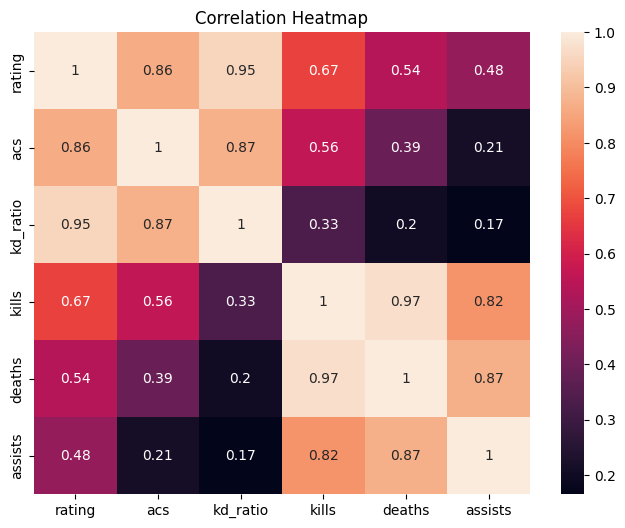

In [34]:
corr = df[['rating','acs','kd_ratio','kills','deaths','assists']].corr()
print("\nCorrelation Matrix:\n", corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Ranking players based on First kills

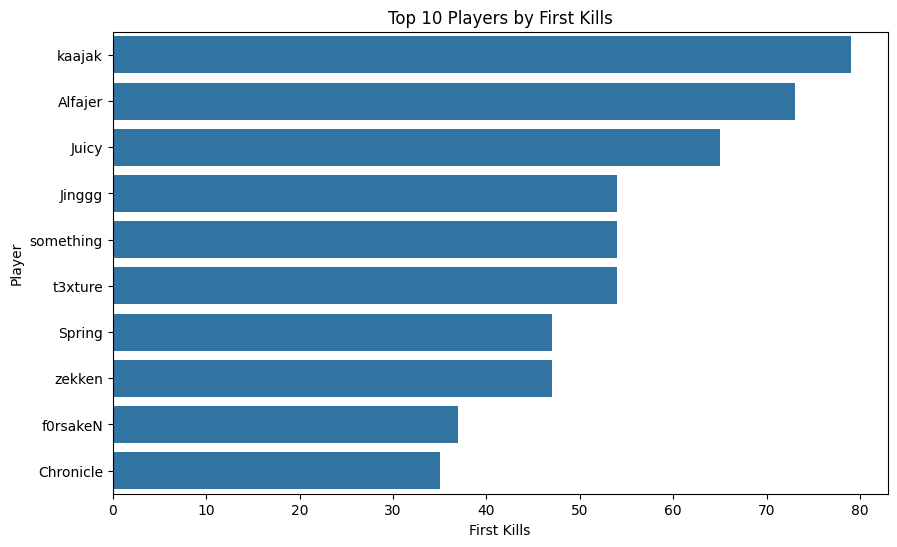

In [8]:
# Sort players by first kills
top_fk = df.sort_values(by='first_kills', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='first_kills', y='player_name', data=top_fk)

plt.title("Top 10 Players by First Kills")
plt.xlabel("First Kills")
plt.ylabel("Player")

plt.show()

# ACS vs Rating correlation

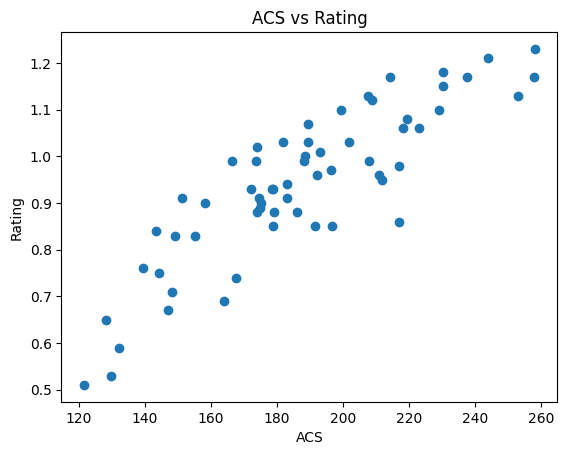

In [36]:
plt.scatter(df['acs'], df['rating'])
plt.xlabel("ACS")
plt.ylabel("Rating")
plt.title("ACS vs Rating")
plt.show()

In [6]:

team_perf = df.groupby('team')['rating'].mean().sort_values(ascending=False)
team_perf = team_perf.drop(['tarik', 'Team'], errors='ignore') #Removing certain teams as they were part of a match seperate from the tournament
print("\nTeam Performance:\n", team_perf)


Team Performance:
 team
PRX     1.052000
FNC     1.046000
SEN     1.044000
G2      1.032000
GEN     1.030000
WOL     0.974000
BLG     0.964000
TL      0.946667
RRQ     0.870000
TH      0.828000
XLG     0.766000
MIBR    0.724000
Name: rating, dtype: float64
